In [1]:
#Dowload the necessary libraries and the CSV
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score



df = pd.read_csv("adult-all.csv") # Reads the adult CSV as it is in the same folder
df.head()

,Age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
#This is the section where it cleans the data for the CSV.

df.columns = df.columns.str.strip().str.lower() # This would standardize the column name and get rid of unnecessary spaces

#Selects columns that are objects, not numbers
categorical_columns = df.select_dtypes(include="object").columns

# It gets rid of any unnecessary spaces in the categorical columns
for column in categorical_columns: 
    df[column] = df[column].str.strip()

#This checks if there are any duplicated rows and removes them
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")
df = df.drop_duplicates().reset_index(drop=True)

#The fnlwgt is dropped because it just represented the sampling weight rather than a characteristic
df = df.drop(columns=["fnlwgt"], errors='ignore')

#The education-num has the same info as education, so education is removed due to redundancy
df = df.drop(columns=["education"],errors='ignore')

#Replaces all of the data that has ? into recognized missing data
df.replace("?",np.nan, inplace = True)

#For each columns that have missing data, run through it to see which data appears
#the most using mode and replace the nan with the data that is most common in that column
missing_columns = ["workclass", "occupation", "native-country"]
for column in missing_columns:
    
    if column in df.columns and df[column].isna().any():
        most_common_value = df[column].mode()[0]
        df[column] = df[column].fillna(most_common_value)

        print(f"{column} missing values replaced with: {most_common_value}")


#This part goes through the numeric columns and change any unexpected text values to NaN
numeric_columns = [ "age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors = "coerce")

#If there are any NaNs within the numerical columns, replace with the median of the columns
for column in numeric_columns:
    if column in df.columns and df[column].isna().any():
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value)
        print(f"{column} missing or invalid values replaced with median: {median_value}")






#Converts the income label where <=50K becomes 0 and >50K becomes 1 show
#which are low- or high-income citizens easier
if df["income"].dtype == "object":
    df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1})


print("\nDataset shape after cleaning:", df.shape)
print("\nRemaining missing values:", df.isna().sum().sum())
print("\nIncome values:", df["income"].unique())

df.head()



Number of exact duplicate rows: 52
workclass missing values replaced with: Private
occupation missing values replaced with: Prof-specialty
native-country missing values replaced with: United-States

Dataset shape after cleaning: (48790, 13)

Remaining missing values: 0

Income values: [0 1]


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [3]:
#Splitting the data into training and test sets

np.random.seed(42) # The random seed is set to 42 to ensure that any random operations will produce the same result each time
# the code is run

census_data = df.drop(columns=["income"]) #The features that is going be used to predict low and high income people
income_labels = df["income"] # This is what we are trying to predict

print(len(census_data))

#randomly arrange all row indices to the len of the census data
indices = np.random.permutation(len(census_data))

#Doing a 70/30 split for the training/test data sets
n_test_samples = int(0.30 * len(census_data))

#Splits the data based on the amount of test samples
train_indices = indices[:-n_test_samples]
test_indices = indices[-n_test_samples:]

# applies the indices to both features and labels
trainset_data = census_data.iloc[train_indices].reset_index(drop=True)
trainset_labels = income_labels.iloc[train_indices].reset_index(drop=True)

testset_data = census_data.iloc[test_indices].reset_index(drop=True)
testset_labels = income_labels.iloc[test_indices].reset_index(drop=True)

print("Training samples:", len(trainset_data))
print("Testing samples:", len(testset_data))

print("\nTraining label distribution:")
print(trainset_labels.value_counts())

print("\nTesting label distribution:")
print(testset_labels.value_counts())

48790
Training samples: 34153
Testing samples: 14637

Training label distribution:
income
0    25907
1     8246
Name: count, dtype: int64

Testing label distribution:
income
0    11202
1     3435
Name: count, dtype: int64


In [4]:
#This section encodes the categorical variables and scale numerical variables

#Finds the categorical columns in the training data
categorical_columns = trainset_data.select_dtypes(include="object").columns

#Finds the numerical columns in the training data
numeric_columns = trainset_data.select_dtypes(exclude="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

print("\nNumerical columns:")
print(numeric_columns.tolist())

# This creates a pre-processing pipeline with two transformers
preprocessor = ColumnTransformer(  
    transformers=[

        #For the categorical columns, it converts each of their variables into dummy variables(one variable per category)
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),

        #Due to some of the numerical columns having different ranges, 
        #The Standard scalar is used so they use a similar scale to prevent
        #larger numerical ranges to have too much influence on distance calculations
        #for KNN
        (
            "numerical",
            StandardScaler(),
            numeric_columns
        )
    ]
)


# Learn the categories, means, and standard deviations
# using only the training data
trainset_processed = preprocessor.fit_transform(trainset_data)

# Apply the same transformations to the test data
testset_processed = preprocessor.transform(testset_data)

#Displays how the number of columns changed after preprocessing
print("\nOriginal training shape:", trainset_data.shape)
print("Processed training shape:", trainset_processed.shape)

print("\nOriginal testing shape:", testset_data.shape)
print("Processed testing shape:", testset_processed.shape)


Categorical columns:
['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Numerical columns:
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Original training shape: (34153, 12)
Processed training shape: (34153, 88)

Original testing shape: (14637, 12)
Processed testing shape: (14637, 88)


In [5]:
# This section uses GirdSearchCV to determine which tested value of K gives
#the highest average cross-validation accuracy for the KNN model

#List of K values that GridSearchCV will compare for the K-nearest neighbor algorithm
#it is short due to it crashing after running for so long but would still take a while
parameter_grid = { "n_neighbors": [3, 4, 5, 7, 9, 11, 15, 21]}

#Creates the initial KNN classifier 
knn = KNeighborsClassifier()

# Create the GridSearch object
grid_search = GridSearchCV(
    estimator=knn, #The model being evaluated
    param_grid = parameter_grid, #The K values tested
    cv=3, # uses 3-fold cross-validation
    scoring="accuracy"  # compare models using accuracy
)

#tests each value of K on the training data
grid_search.fit(trainset_processed, trainset_labels)

# displays the K value with highest cross validation accuracy and what it  acheived 
print("Best K:", grid_search.best_params_["n_neighbors"])
print(
    f"Best cross-validation accuracy: "
    f"{grid_search.best_score_:.2%}"
)



Best K: 21
Best cross-validation accuracy: 84.51%


In [6]:
# This cell would use the KNN mode with k value that gives the best accuracy on the 
#training data to be used on the test data sets 

#Retrieves the KNN model that had the highest cross-validation from GridSearchCV
best_knn_model = grid_search.best_estimator_

#Used the selected KNN model to predict income labels for data in the test set
predicted_labels = best_knn_model.predict(testset_processed)

# Reset the index of the actual test labels so that they
# line up with the positions of the predicted labels.
actual_labels = testset_labels.reset_index(drop=True)

# Display the first 15 test samples. The number could be replaced with len(n_test_samples
# but would produce a very long output that would take quite some time
for row in range(15):
    print(
        f"Test sample {row + 1}: "
        f"Predicted = {predicted_labels[row]}, " #Shows the predicted labels done by KNN
        f"Actual = {actual_labels.iloc[row]}, " # Shows the actual label to compare
        f"Match = {predicted_labels[row] == actual_labels.iloc[row]}" # Checks to see if they match or not
    )

# compares all predicted labels with all actual labels to calculate the final accuracy
# on the test set
test_accuracy = accuracy_score(
    actual_labels,
    predicted_labels
    
)
print("\nSelected K:", grid_search.best_params_["n_neighbors"]) # Shows what value K that was selected by GridSearchCV
print(f"Test accuracy: {test_accuracy:.2%}") #Shows the accuracy percentage


Test sample 1: Predicted = 0, Actual = 0, Match = True
Test sample 2: Predicted = 0, Actual = 0, Match = True
Test sample 3: Predicted = 0, Actual = 0, Match = True
Test sample 4: Predicted = 0, Actual = 0, Match = True
Test sample 5: Predicted = 0, Actual = 0, Match = True
Test sample 6: Predicted = 0, Actual = 0, Match = True
Test sample 7: Predicted = 0, Actual = 0, Match = True
Test sample 8: Predicted = 1, Actual = 1, Match = True
Test sample 9: Predicted = 0, Actual = 0, Match = True
Test sample 10: Predicted = 1, Actual = 1, Match = True
Test sample 11: Predicted = 0, Actual = 0, Match = True
Test sample 12: Predicted = 0, Actual = 1, Match = False
Test sample 13: Predicted = 1, Actual = 1, Match = True
Test sample 14: Predicted = 0, Actual = 0, Match = True
Test sample 15: Predicted = 0, Actual = 0, Match = True

Selected K: 21
Test accuracy: 84.85%


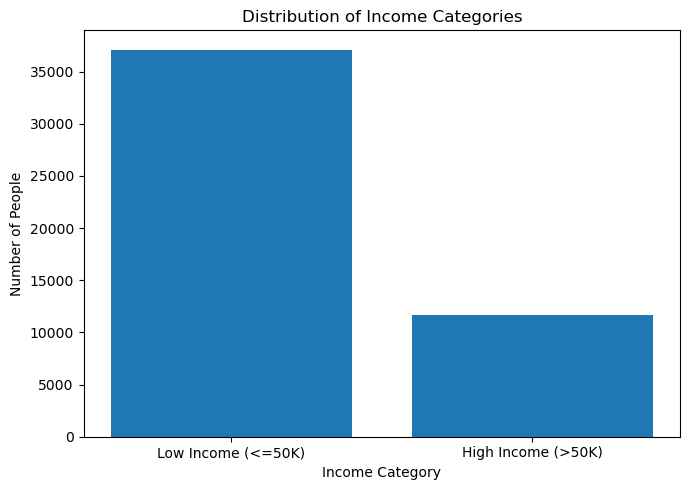

In [7]:
#Shows the distribution of the income categories

# Counts how many observations belong to each income category
#the sort_index keeps 0(low income( before 1(high income)
income_counts = df["income"].value_counts().sort_index()

plt.figure(figsize=(7, 5)) # makes figure with 7 inches wide and 5 inches tall

#Creates a bar chart that shows the # of people in low- and high-income categories
plt.bar(
    ["Low Income (<=50K)", "High Income (>50K)"],
    income_counts
)
#Adds labels and title to the graph
plt.xlabel("Income Category")
plt.ylabel("Number of People")
plt.title("Distribution of Income Categories")
#adjusts the spacing so labels aren't cut offf
plt.tight_layout()
plt.show()# displays completed graph

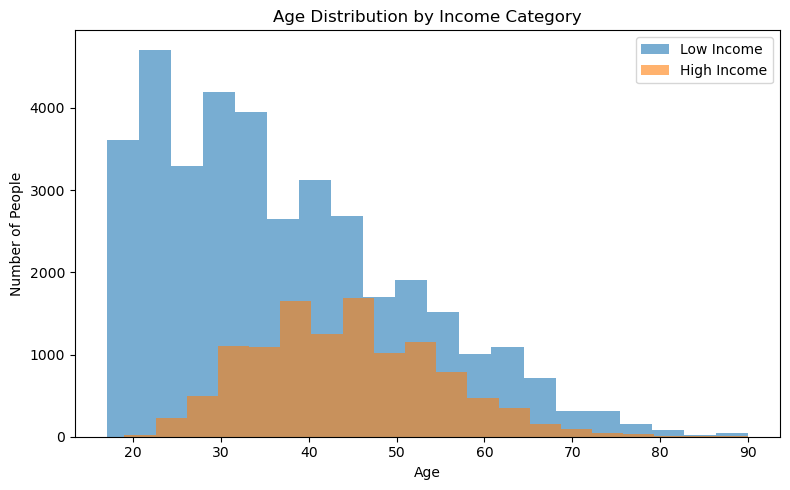

In [8]:
#Shows a histogram comparing income groups by the number of people in them by age


plt.figure(figsize=(8, 5))

# Plots the ages of people in the low-income category.
plt.hist(
    df.loc[df["income"] == 0, "age"],
    bins=20, #divides the age range into 20 intervals
    alpha=0.6, # the tranparancy level
    label="Low Income"
)

# Plots the ages of people in the high-income category.
plt.hist(
    df.loc[df["income"] == 1, "age"],
    bins=20, #divides the age range into 20 intervals
    alpha=0.6, # the tranparancy level
    label="High Income"
)

# Label the axes and add a title.
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.title("Age Distribution by Income Category")

#Displays the labels for the two income groups
plt.legend()
plt.tight_layout() # adjusts spacing so the labels aren't cut off
plt.show()